In [ ]:
%load_ext autoreload
%autoreload 2

import logging
from pathlib import Path

import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import scipy.stats as stats
from matplotlib import pyplot as plt
from matplotlib.figure import Figure
from matplotlib.patches import Patch

from analyze_sectors_ts import (  # noqa: F401
    collect_points_time_series,
    collect_statistics,
    create_sectors_evolution_mosaic,
    create_time_series_plot,
    find_result_folders,
    load_sector_results,
    plot_area_panel,
    plot_sector_evolution_boxplots,
    plot_swimmer_all_sectors,
    plot_velocity_panel,
    plot_velocity_separation_panel,
)
from ppcluster import load_config, setup_logger

%matplotlib widget

logger = setup_logger(logging.INFO, name="ppcx")

input_dir = Path("output/2019")
output_dir = input_dir / "kinematic_sectors_time_series"

config = load_config()

if not input_dir.exists():
    raise FileNotFoundError(f"Input directory not found: {input_dir}")

output_dir.mkdir(parents=True, exist_ok=True)

UNIT = "px"
UNIT_SCALE = 1.0  # 1 for px, or the m/px conversion factor

dir_pattern = r"PPCX_Tele_\d{4}-\d{2}-\d{2}$"
results_pattern = "*results.joblib"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
# Find result folders
logger.info(f"Searching for result folders in {input_dir}...")
folders = find_result_folders(input_dir, pattern=dir_pattern)
logger.info(f"Found {len(folders)} result folders")

# Load results from all dates
logger.info("Loading results from all dates...")
results_list = []
for folder in folders:
    result = load_sector_results(folder, search_pattern=results_pattern)
    if result is not None:
        results_list.append(result)

logger.info(f"Successfully loaded {len(results_list)} / {len(folders)} results")

2026-01-30 11:38:03 | [INFO    ] Searching for result folders in output/2019...
2026-01-30 11:38:03 | [INFO    ] Found 144 result folders
2026-01-30 11:38:03 | [INFO    ] Loading results from all dates...
2026-01-30 11:38:03 | [ERROR   ] Failed to load results from output/2019/PPCX_Tele_2019-06-10: No bundle file found in output/2019/PPCX_Tele_2019-06-10
2026-01-30 11:38:03 | [ERROR   ] Failed to load results from output/2019/PPCX_Tele_2019-06-11: No bundle file found in output/2019/PPCX_Tele_2019-06-11
2026-01-30 11:38:03 | [ERROR   ] Failed to load results from output/2019/PPCX_Tele_2019-09-13: No bundle file found in output/2019/PPCX_Tele_2019-09-13
2026-01-30 11:38:03 | [ERROR   ] Failed to load results from output/2019/PPCX_Tele_2019-09-21: No bundle file found in output/2019/PPCX_Tele_2019-09-21
2026-01-30 11:38:03 | [ERROR   ] Failed to load results from output/2019/PPCX_Tele_2019-10-15: No bundle file found in output/2019/PPCX_Tele_2019-10-15
2026-01-30 11:38:03 | [ERROR   ] Fa

In [16]:
# Collect sector statistics into a DataFrame
df_sectors = collect_statistics(results_list)
logger.info(
    f"Successfully loaded {len(df_sectors)} records from {len(df_sectors['date'].unique())} dates"
)

# Collect point-level time series data
df_points_ts = collect_points_time_series(results_list)
columns_to_drop = ["geometry", "cluster_id", "area"]
df_points_ts = df_points_ts.drop(columns=columns_to_drop, errors="ignore")

logger.info(f"Points time series shape: {df_points_ts.shape}")
logger.info(f"Columns: {df_points_ts.columns.tolist()}")

2026-01-30 11:38:04 | [INFO    ] Successfully loaded 512 records from 128 dates
2026-01-30 11:38:04 | [INFO    ] Collected 275958 points across 128 dates and 4 sectors
2026-01-30 11:38:04 | [INFO    ] Points time series shape: (275958, 7)
2026-01-30 11:38:04 | [INFO    ] Columns: ['x', 'y', 'u', 'v', 'V', 'sector', 'date']


2026-01-30 11:38:10 | [INFO    ] Saved distribution evolution plot to output/2019/kinematic_sectors_time_series/sectors_velocity_boxplot_evolution.png


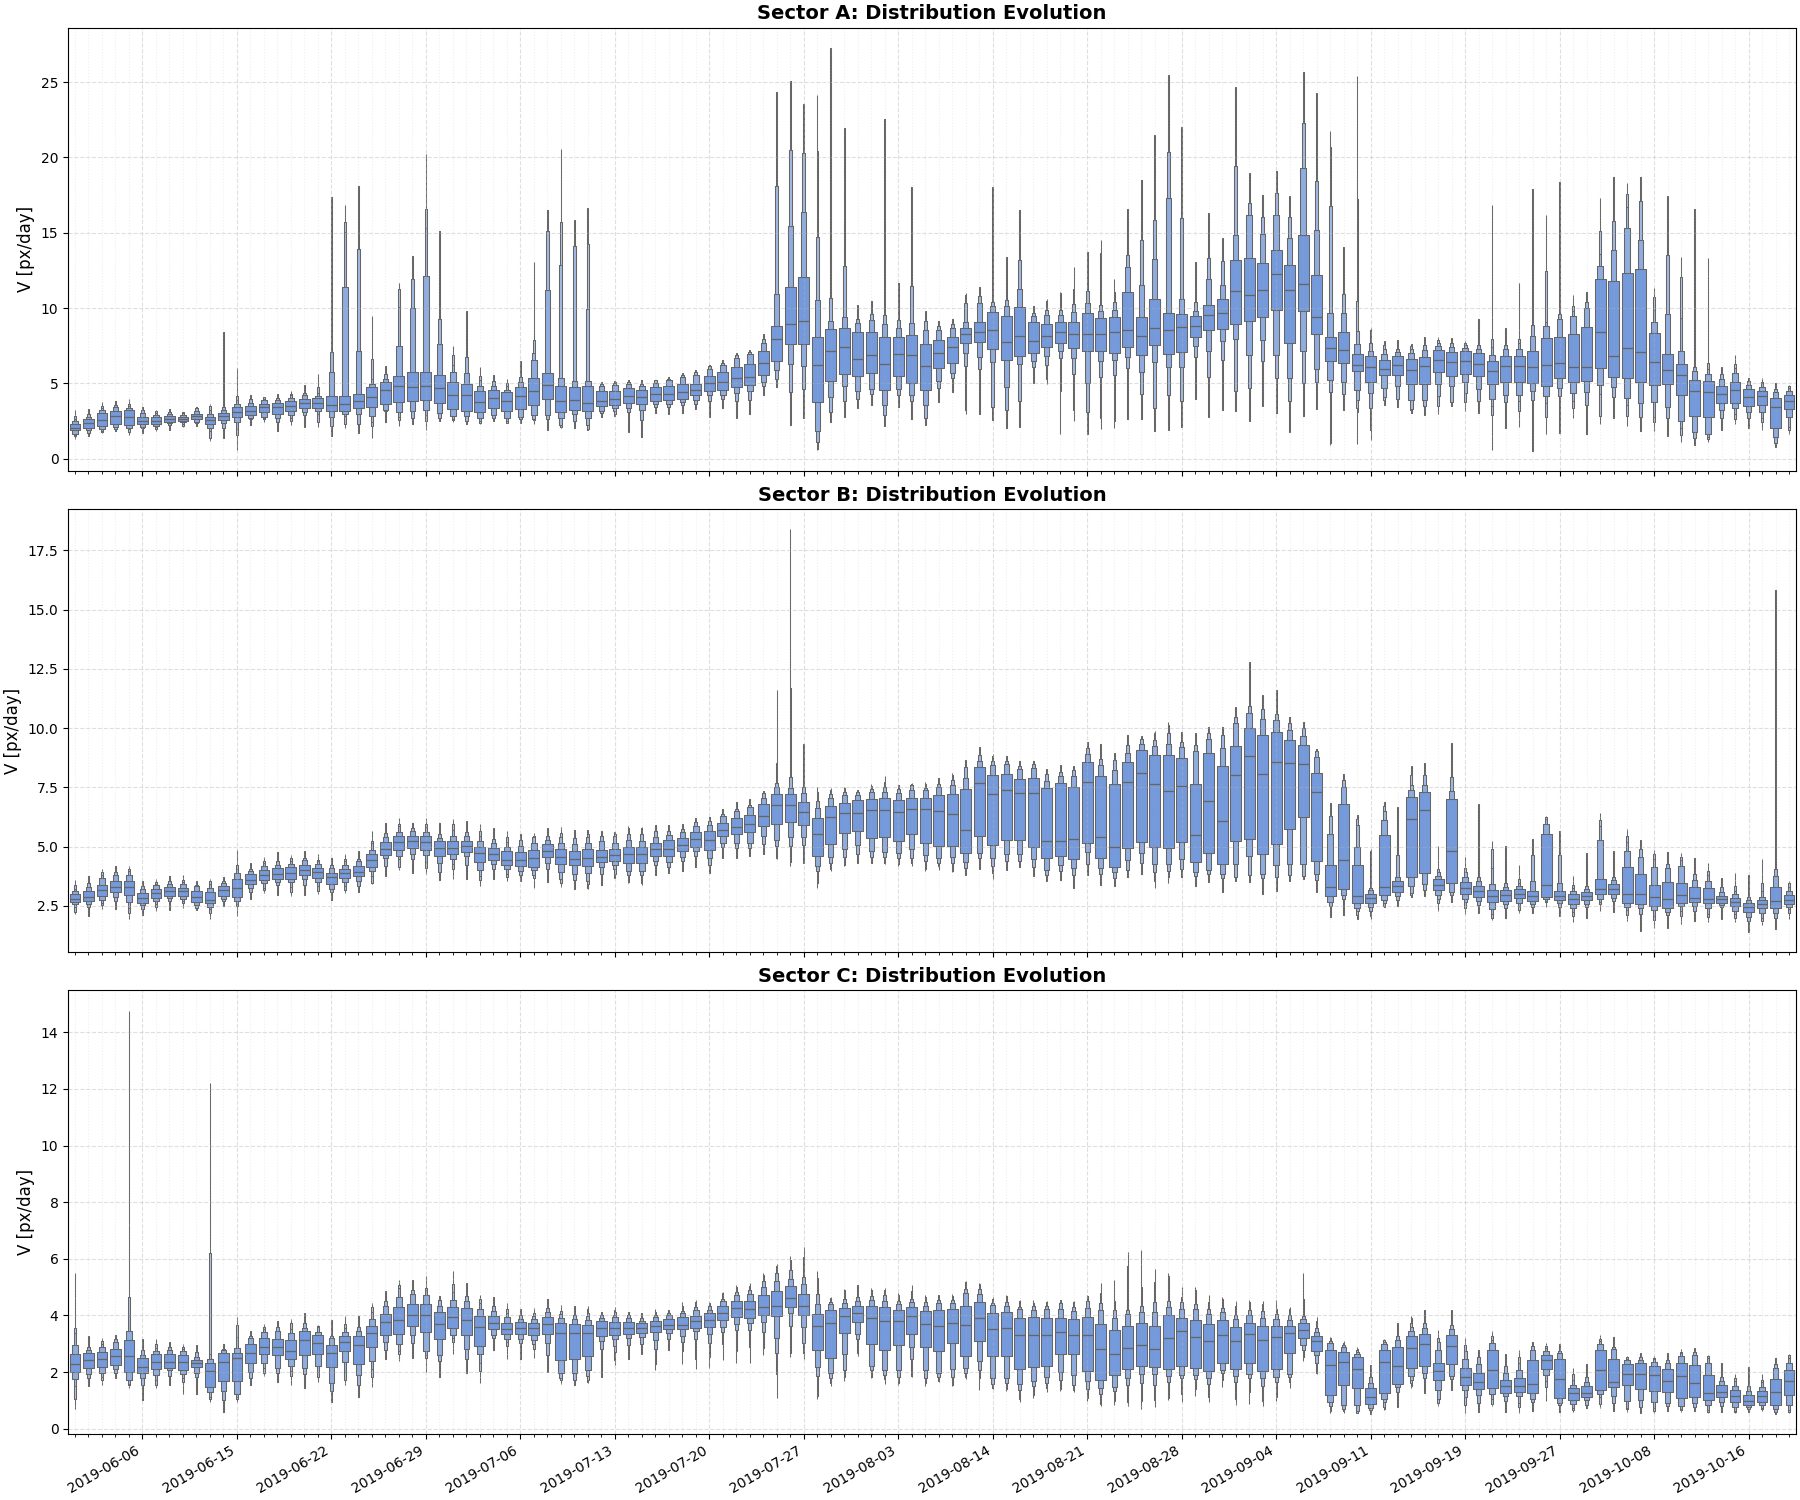

In [17]:
_ = plot_sector_evolution_boxplots(
    df_points_ts,
    col="V",
    unit=UNIT,
    sectors=["A", "B", "C"],
    output_path=output_dir / "sectors_velocity_boxplot_evolution.png",
)


In [18]:
# date_sel = pd.to_datetime("2020-08-02")
# _ = plot_single_date_sector_distributions(
#     df_points_ts,
#     date_sel,
#     sectors=["A", "B", "C"],
#     col="V",
# )


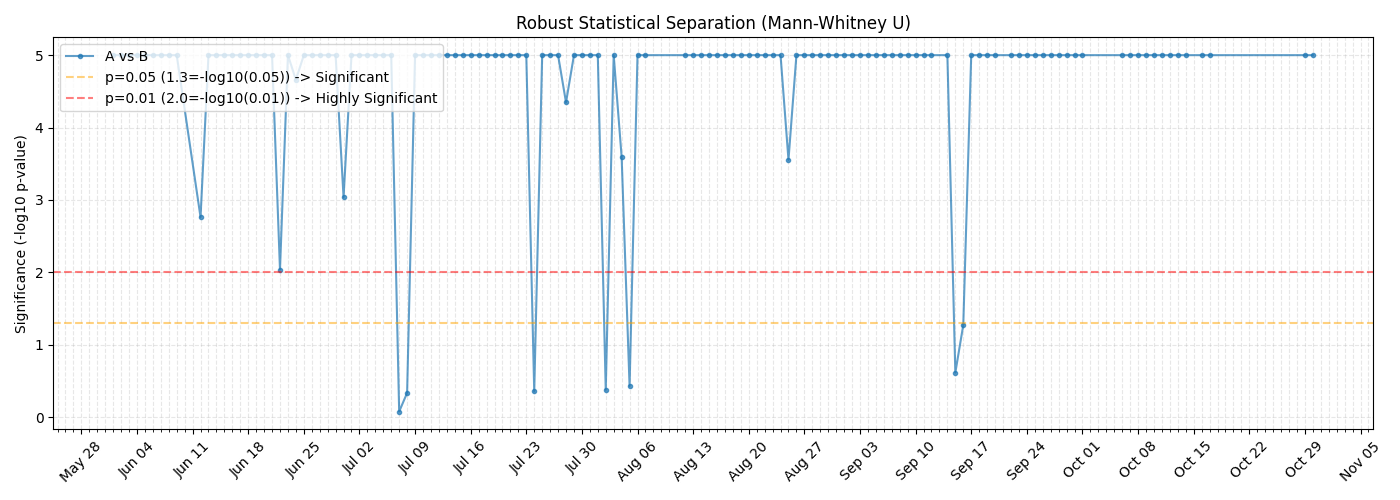

In [19]:
### SANDBOX for statistical testing of sector separation over time

df_points = df_points_ts.copy()
sec1, sec2 = "A", "B"
rolling_days = None

# Group by date to perform the test daily
dates = sorted(df_points["date"].unique())
p_values = []
valid_dates = []
for date in dates:
    # Extract velocities for the specific day and sectors
    v1 = df_points[(df_points["date"] == date) & (df_points["sector"] == sec1)][
        "V"
    ].dropna()
    v2 = df_points[(df_points["date"] == date) & (df_points["sector"] == sec2)][
        "V"
    ].dropna()

    # Filter out outliers (>+-0.05 percentile)

    # Need minimal data points to run the test
    if len(v1) < 5 or len(v2) < 5:
        continue

    # Mann-Whitney U Test
    # alternative='two-sided' checks if distributions are different
    try:
        stat, p = stats.mannwhitneyu(v1, v2, alternative="two-sided")
        p_values.append(p)
        valid_dates.append(date)
    except ValueError:
        continue

if not valid_dates:
    logger.warning(f"No valid data to test separation for {sec1} vs {sec2}")

# Convert to numpy array for processing
p_values = np.array(p_values)

# Avoid log(0)
p_values = np.where(p_values == 0, 1e-300, p_values)

label = f"{sec1} vs {sec2}"

# Plot -log10(p-value) for better visualization
# High value = High significance (Separated)
# Low value = Low significance (Merged/Same)
significance_score = -np.log10(p_values)

if rolling_days is not None:
    s_sig = pd.Series(significance_score, index=valid_dates)
    significance_score = (
        s_sig.rolling(window=f"{rolling_days}D", center=True).median().values
    )
    label += f" ({rolling_days}d median)"

fig, ax = plt.subplots(figsize=(14, 5))

# Cap the significance score for better visualization
significance_score_plt = np.clip(significance_score, 0, 5)

ax.plot(valid_dates, significance_score_plt, label=label, marker=".", alpha=0.7)

# Threshold lines
# p = 0.05 -> -log10(0.05) ~= 1.3
# p = 0.01 -> -log10(0.01) = 2.0
ax.axhline(
    1.3,
    color="orange",
    linestyle="--",
    alpha=0.5,
    label="p=0.05 (1.3=-log10(0.05)) -> Significant",
)
ax.axhline(
    2.0,
    color="red",
    linestyle="--",
    alpha=0.5,
    label="p=0.01 (2.0=-log10(0.01)) -> Highly Significant",
)

ax.set_ylabel("Significance (-log10 p-value)")
ax.set_title("Robust Statistical Separation (Mann-Whitney U)")
ax.legend(loc="upper left")
ax.grid(True, which="both", linestyle="--", alpha=0.3)

# x-axis formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_minor_locator(mdates.DayLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
from ppcluster.sectors import get_sector_colors

sector_names = df_sectors["sector"].unique().tolist()
colors = get_sector_colors(
    sector_names,
    colormap="tab10",
)

2026-01-30 11:41:52 | [INFO    ] Saved sector time series to output/2019/kinematic_sectors_time_series/sectors_time_series.png


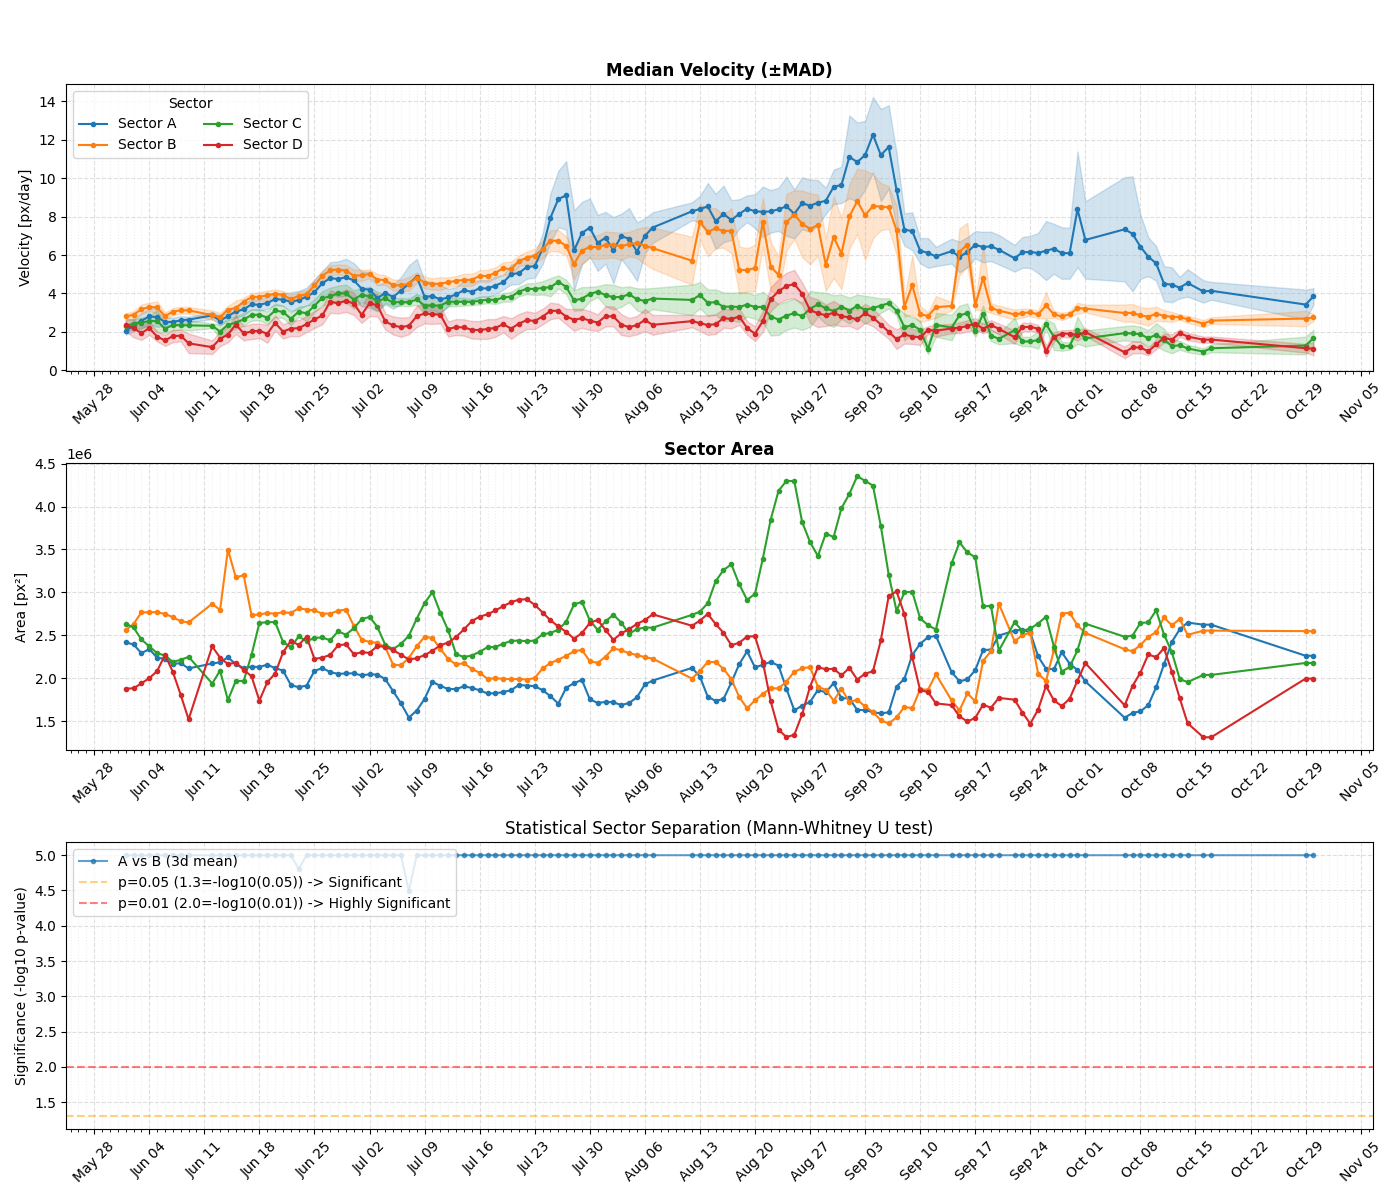

In [29]:
# Figure with time series of velocity and area of each sector
output_path = output_dir / "sectors_time_series.png"
create_time_series_plot(
    df_sectors,
    df_points_ts,
    output_path,
    unit=UNIT,
    sector_colors=colors,
    sector_pairs=[("A", "B")],
    rolling_days_area=3,
    rolling_days_sep=3,
    rolling_function="mean",
    show=True,
)


# Manual plot
# fig, axes = plt.subplots(3, 1, figsize=(14, 12))
# ax1, ax2, ax3 = axes
# plot_velocity_panel(
#     ax1,
#     df_sectors,
#     colors,
#     unit=f"{UNIT}/day",
# )
# plot_area_panel(
#     ax2,
#     df_sectors,
#     colors,
#     unit=f"{UNIT}²",
#     rolling_days=3,
#     rolling_function="mean",
# )
# plot_velocity_separation_panel(
#     ax3,
#     df_points=df_points_ts,
#     sector_pairs=[("A", "B")],
#     rolling_days=3,
#     rolling_function="mean",
# )


# plt.tight_layout()
# fig.savefig(output_path, dpi=300)
# fig.savefig(output_path.with_suffix(".svg"), bbox_inches="tight")
# logger.info(f"Saved sector time series to {output_path}")

2026-01-30 11:38:28 | [INFO    ] Using fixed area bin size 1000000: bins [1000000. 2000000. 3000000. 4000000. 5000000.]


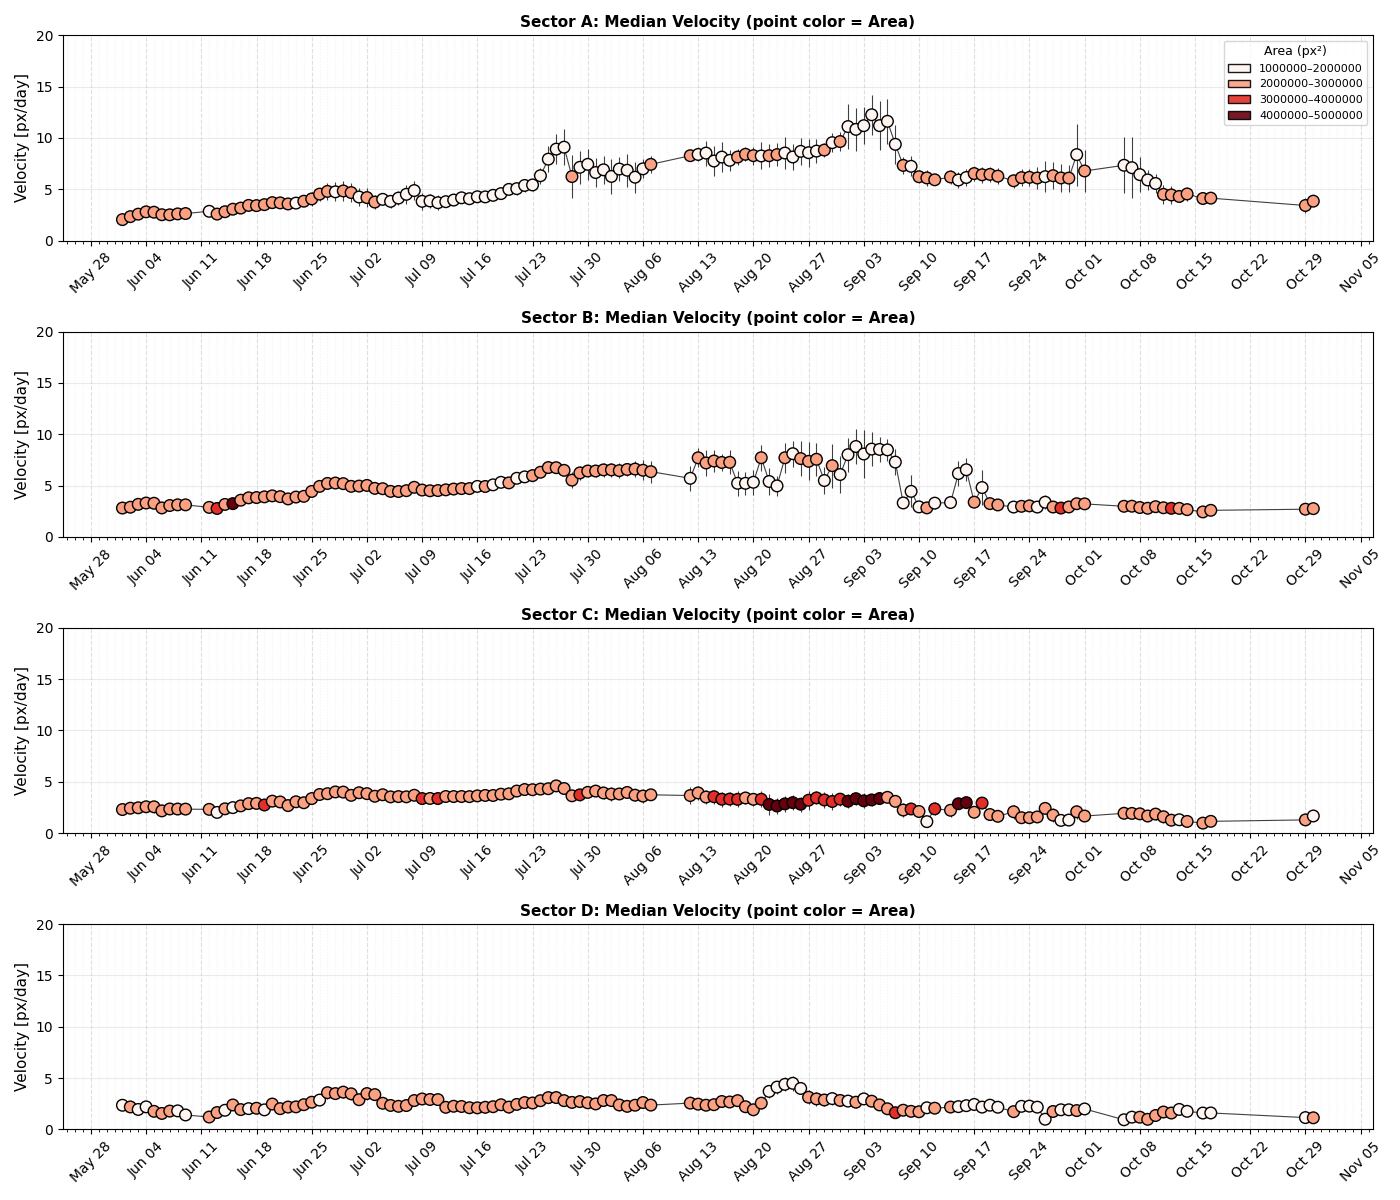

In [21]:
def plot_sectors_velocity_area_time_series(
    df_sectors: pd.DataFrame,
    output_path: Path,
    area_bin_size: int | None = 1_000_000,
    area_bin_edges: list[float] | None = None,
    fallback_n_bins: int = 5,
    max_panels: int = 4,
    unit: str = UNIT,
    save_svg: bool = True,
) -> Figure:
    """
    Plot median velocity time series for each sector (one panel per sector),
    with point color indicating sector area bins.

    Returns the created matplotlib Figure.
    """
    if df_sectors.empty or "sector" not in df_sectors.columns:
        logger.warning("No sector data available for plotting")
        return plt.figure()

    # compute global area range (ignore NaNs) using the DataFrame column
    if "area_px2" not in df_sectors.columns:
        all_areas = np.array([])
    else:
        all_areas = df_sectors["area_px2"].dropna().values.astype(float)

    if all_areas.size == 0:
        min_a, max_a = 0.0, 1.0
    else:
        min_a, max_a = float(np.min(all_areas)), float(np.max(all_areas))
        if np.isclose(min_a, max_a):
            max_a = min_a + 1.0

    # Decide bins
    if area_bin_edges is not None:
        bins = np.asarray(area_bin_edges, dtype=float)
        logger.info(f"Using user-provided area bin edges: {bins}")
    elif area_bin_size:
        start = np.floor(min_a / area_bin_size) * area_bin_size
        stop = np.ceil(max_a / area_bin_size) * area_bin_size
        if start == stop:
            stop = start + area_bin_size
        bins = np.arange(start, stop + area_bin_size, area_bin_size)
        logger.info(f"Using fixed area bin size {area_bin_size}: bins {bins}")
    else:
        bins = np.linspace(min_a, max_a, fallback_n_bins + 1)
        logger.info(f"Using fallback linear bins (n={fallback_n_bins}): {bins}")

    n_bins = max(1, len(bins) - 1)
    cmap = plt.get_cmap("Reds", n_bins)
    colors_list = [cmap(i) for i in range(n_bins)]

    # Get unique sectors and limit panels
    sectors = sorted(df_sectors["sector"].unique())
    n_sectors = len(sectors)
    n_panels = min(max_panels, n_sectors)

    fig, axes = plt.subplots(n_panels, 1, figsize=(14, 3 * n_panels), squeeze=False)
    axes = axes.flatten()

    # create legend patches for area bins (one-time)
    area_patches = []
    for i in range(n_bins):
        low, high = bins[i], bins[i + 1]
        label = f"{low:.0f}–{high:.0f}"
        area_patches.append(
            Patch(facecolor=colors_list[i], edgecolor="k", label=label, alpha=0.9)
        )

    for ax, sector in zip(axes, sectors[:n_panels], strict=False):
        subset = df_sectors[df_sectors["sector"] == sector].sort_values("date")

        dates_dt = subset["date"]
        v_median = subset["v_median"].to_numpy(dtype=float)
        v_mad = subset["v_mad"].to_numpy(dtype=float)
        area = subset.get("area_px2", pd.Series(np.nan, index=subset.index)).to_numpy(
            dtype=float
        )

        # bin areas into discrete colors using numpy.digitize
        safe_area = np.nan_to_num(area, nan=bins[0])
        bin_idx = np.digitize(safe_area, bins) - 1  # index in 0..n_bins-1
        bin_idx = np.clip(bin_idx, 0, n_bins - 1)
        colors_area = [colors_list[i] for i in bin_idx]

        ax.errorbar(
            dates_dt,
            v_median,
            yerr=v_mad,
            markersize=0,
            linestyle="-",
            linewidth=0.8,
            label=f"Sector {sector}",
            color="k",
            alpha=0.75,
        )
        ax.scatter(
            dates_dt,
            v_median,
            s=70,
            c=colors_area,
            edgecolors="k",
            zorder=3,
        )

        ax.set_ylabel(f"Velocity [{unit}/day]", fontsize=11)
        ax.set_title(
            f"Sector {sector}: Median Velocity (point color = Area)",
            fontsize=11,
            weight="bold",
        )
        ax.grid(axis="y", alpha=0.25)

        # x-axis formatting
        major_locator = mdates.WeekdayLocator(interval=1)
        major_formatter = mdates.DateFormatter("%b %d")
        ax.xaxis.set_major_locator(major_locator)
        ax.xaxis.set_major_formatter(major_formatter)
        ax.xaxis.set_minor_locator(mdates.DayLocator())
        ax.grid(axis="x", which="major", linestyle="--", alpha=0.4)
        ax.grid(axis="x", which="minor", linestyle=":", alpha=0.15)

        ax.tick_params(axis="x", rotation=45, labelbottom=True)

        # Optional: consistent y-limits for better comparison
        if len(v_median) > 0:
            ax.set_ylim([0, max(20, np.nanmax(v_median) + 5)])  # simple fallback

    # place area color legend in the first axis (clear and compact)
    if axes.size > 0:
        axes[0].legend(
            handles=area_patches,
            title=f"Area ({unit}²)",
            loc="best",
            fontsize=8,
            title_fontsize=9,
        )

    fig.tight_layout()

    # Save
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    if save_svg:
        fig.savefig(output_path.with_suffix(".svg"), bbox_inches="tight")

    return fig


# Replace inline block with a single function call
output_path = output_dir / "sectors_velocity_area_time_series.png"
fig = plot_sectors_velocity_area_time_series(df_sectors, output_path)

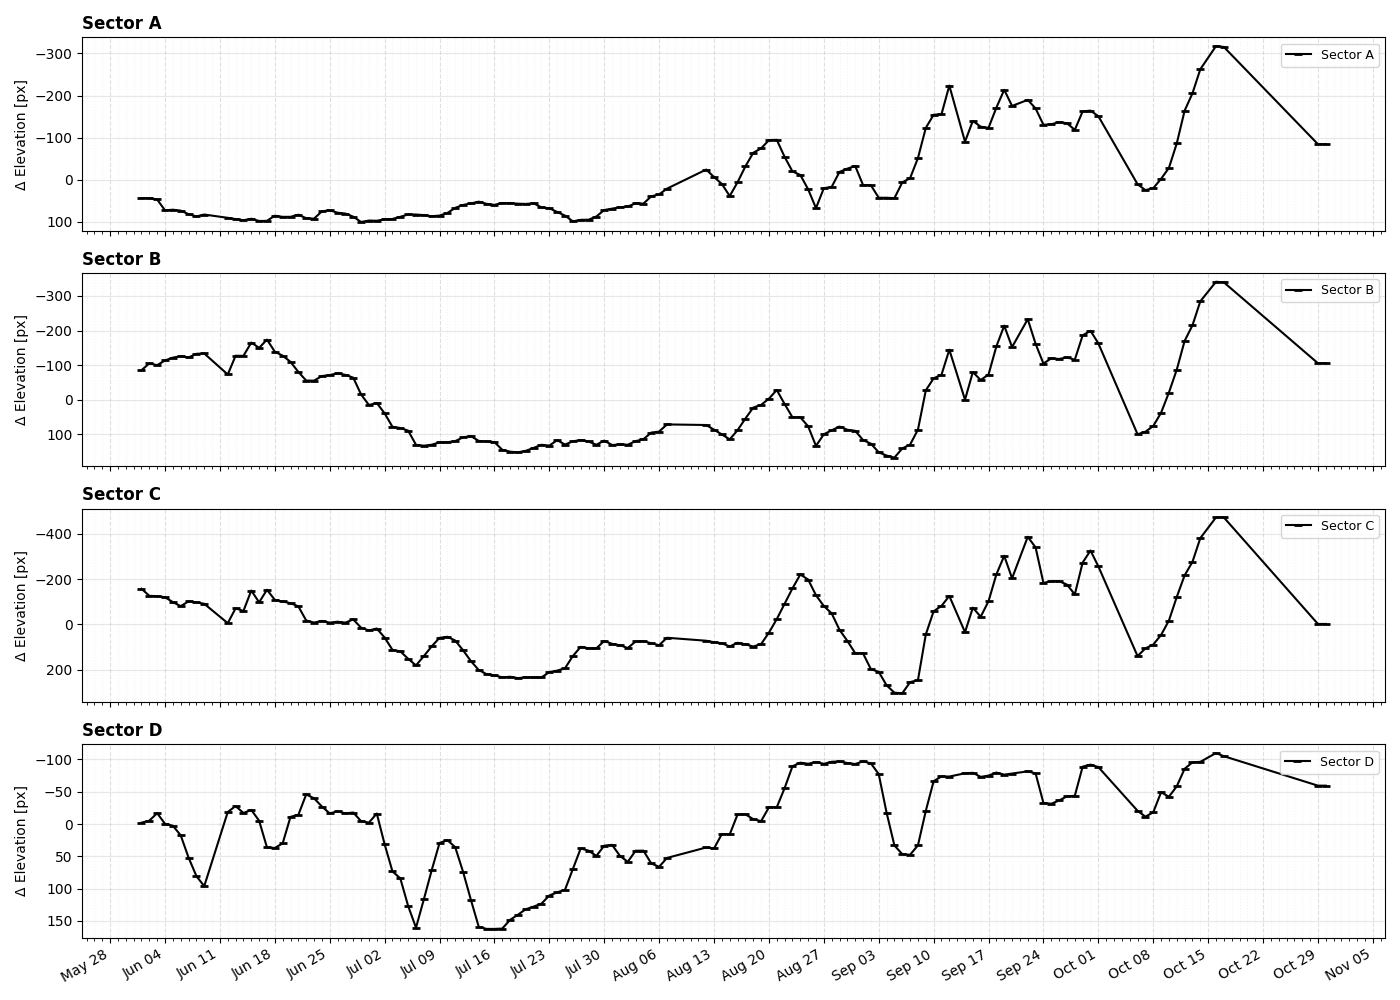

In [22]:
# Swimmer plot: vertical movement of sectors' centroid over time
fig_separate = plot_swimmer_all_sectors(
    df_sectors,
    colors,
    plot_sector_extent=False,
    subtract_mean=True,
    rolling_days=5,
)
fig_separate.savefig(output_dir / "sectors_centroid_location.png", dpi=300)

In [23]:
# Generate mosaic for all available data
output_path_mosaic = output_dir / "sectors_evolution_mosaic"
plt.close("all")  # close any existing figures
# create_sectors_evolution_mosaic(
#     df_sectors,
#     output_path_mosaic,
#     image=None,
#     df_points=df_points_ts,
#     max_dates_per_figure=30,
#     ncols=6,
#     nrows=None,
#     velocity_mode="scatter",
#     velocity_cmap="Blues",
#     min_cbar=0.0,
#     max_cbar=10.0,
#     img_kwargs=None,
#     quiver_kwargs=None,
#     scatter_kwargs={"s": 10, "alpha": 0.6},
#     sector_kwargs=None,
#     sector_fill_kwargs={"alpha": 0},
#     sector_edge_kwargs={"linewidth": 5.0},
#     save_svg=False,
#     n_jobs=1,
# )